In [1]:
import pandas as pd
psalm_verses = pd.read_csv("data/cleaned_psalm_verses.csv")
psalm_verses

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,tradition,text,psalm_num,verse_num,verse
0,Orthodox,Bible,1,1,Blessed is the man Who walks not in the counse...
1,Orthodox,Bible,1,2,But his will is in the law of the Lord And in ...
2,Orthodox,Bible,1,3,He shall be like a tree Planted by streams of ...
3,Orthodox,Bible,1,4,Not so are the ungodly not so But they are lik...
4,Orthodox,Bible,1,5,Therefore the ungodly shall not rise in the ju...
...,...,...,...,...,...
4937,Orthodox,Psalter,150,1,Praise God in His holy ones; praise Him in the...
4938,Orthodox,Psalter,150,2,Praise Him for His mighty acts; praise Him acc...
4939,Orthodox,Psalter,150,3,Praise Him with the sound of the trumpet; prai...
4940,Orthodox,Psalter,150,4,Praise Him with the timbrel and dance; praise ...


In [2]:
psalms = pd.read_csv("data/grouped_psalm.csv")
psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...
...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio..."
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ..."


In [3]:
TAG_MAP = {
    # NOUNS
    'NN': 'common_noun',
    'NNS': 'common_noun_plural',
    'NNP': 'proper_noun',
    'NNPS': 'proper_noun_plural',

    # VERBS
    'VB': 'verb_base',
    'VBD': 'verb_past',
    'VBG': 'verb_gerund',
    'VBN': 'verb_participle',
    'VBP': 'verb_present',
    'VBZ': 'verb_3sg',
    'MD': 'modal',

    # ADJECTIVES
    'JJ': 'adjective',
    'JJR': 'comparative_adj',
    'JJS': 'superlative_adj',

    # ADVERBS
    'RB': 'adverb',
    'RBR': 'comparative_adv',
    'RBS': 'superlative_adv',
    'WRB': 'wh_adverb',

    # PRONOUNS
    'PRP': 'personal_pronoun',
    'PRP$': 'possessive_pronoun',
    'WP': 'wh_pronoun',
    'WP$': 'possessive_wh_pronoun',

    # DETERMINERS
    'DT': 'determiner',
    'WDT': 'wh_determiner',
    'PDT': 'predeterminer',

    # PREPOSITIONS / CONJUNCTIONS
    'IN': 'preposition',
    'CC': 'coordinating_conjunction',

    # PARTICLES
    'RP': 'particle',
    'TO': 'infinitive_to',

    # NUMBERS
    'CD': 'cardinal_number',

    # EXISTENTIALS
    'EX': 'existential_there',

    # INTERJECTIONS
    'UH': 'interjection',

    # FOREIGN WORDS
    'FW': 'foreign_word',

    # LIST MARKERS
    'LS': 'list_marker',

    # POSSESSIVE ENDINGS
    'POS': 'possessive_ending',

    # SYMBOLS
    '$': 'currency_symbol',
    '#': 'hash_symbol',
    'SYM': 'symbol',

    # PUNCTUATION
    '.': 'sentence_end',
    ',': 'comma',
    ':': 'colon_semicolon',
    '(': 'left_paren',
    ')': 'right_paren',
    '``': 'open_quote',
    "''": 'close_quote'
}

In [4]:
import nltk
from nltk.tokenize import word_tokenize


def tag_word(word):
    token = word_tokenize(word)
    # Get the raw tag (e.g., 'NN' or 'JJ')
    raw_tag = nltk.pos_tag(token)[0][1]
    
    # Return the mapped name, or 'other' if it isn't a noun or adjective
    return TAG_MAP.get(raw_tag, 'other')

# Examples
print(tag_word("apple"))  # Output: noun
print(tag_word("quick"))  # Output: adjective
print(tag_word("run"))    # Output: other

common_noun
common_noun
verb_base


# Correspondence Analysis of Part-of-Speech Distributions

Correspondence Analysis (CA) is a multivariate statistical technique used to explore relationships between categorical variables. In this study, CA is applied to part-of-speech (POS) frequencies extracted from the Bible and Psalter translations of the Psalms.

The analysis begins by counting the occurrences of major POS categories (e.g., nouns, verbs, adjectives, adverbs, and pronouns) within each Psalm. These frequencies are then organized into a contingency table, where rows represent individual Psalms (or topics) and columns represent POS categories.

CA projects both Psalms and POS categories into a lower-dimensional space, allowing patterns in grammatical style to be visualized and interpreted. Psalms located near specific POS categories exhibit a stronger association with those grammatical features.

The primary goal is to determine whether the Bible and Psalter translations differ in their grammatical profiles. In particular, the analysis investigates whether one translation tends toward a more nominal style (characterized by nouns, adjectives, and determiners) or a more verbal style (characterized by verbs, pronouns, and adverbs).

By reducing complex POS frequency data into a small number of interpretable dimensions, Correspondence Analysis provides a quantitative method for examining stylistic differences between translations and identifying broader linguistic patterns across the Psalms.

In [5]:
ca_df = pd.DataFrame(index=[0], columns=['Psalm', 'Translation'])

# target_psalm = psalms['verse'].iloc[0]

In [6]:
from collections import Counter

def tag_text(psalm, num, trans):
    counts = Counter()

    for word in psalm.split():
        pos = tag_word(word)
        counts[pos] += 1

    row = {
        'Psalm': num,
        'Translation': trans,
        **counts
    }

    return row


In [7]:
rows = []

for _, row in psalms.iterrows():
    rows.append(
        tag_text(
            row['verse'],
            row['psalm_num'],
            row['text']
        )
    )
    

ca_df = pd.DataFrame(rows).fillna(0)

ca_df.head()

,Psalm,Translation,verb_participle,verb_3sg,determiner,common_noun,wh_pronoun,common_noun_plural,adverb,preposition,...,verb_past,superlative_adj,proper_noun,existential_there,cardinal_number,comparative_adj,comparative_adv,possessive_wh_pronoun,interjection,sentence_end
0,1,Bible,2.0,3.0,24,27,1.0,11,12.0,22,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Bible,5.0,0.0,21,52,2.0,15,5.0,26,...,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Bible,2.0,3.0,14,39,6.0,7,5.0,19,...,1.0,0.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,Bible,4.0,0.0,8,48,3.0,8,3.0,23,...,4.0,0.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4,5,Bible,2.0,3.0,22,74,4.0,8,6.0,39,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
ca_df.columns

Index(['Psalm', 'Translation', 'verb_participle', 'verb_3sg', 'determiner',
       'common_noun', 'wh_pronoun', 'common_noun_plural', 'adverb',
       'preposition', 'coordinating_conjunction', 'possessive_pronoun',
       'modal', 'personal_pronoun', 'verb_base', 'wh_determiner',
       'verb_present', 'adjective', 'wh_adverb', 'verb_gerund',
       'infinitive_to', 'verb_past', 'superlative_adj', 'proper_noun',
       'existential_there', 'cardinal_number', 'comparative_adj',
       'comparative_adv', 'possessive_wh_pronoun', 'interjection',
       'sentence_end'],
      dtype='str')

In [11]:
pos_cols = ['verb_participle', 'verb_3sg', 'determiner',
       'common_noun', 'wh_pronoun', 'common_noun_plural', 'adverb',
       'preposition', 'coordinating_conjunction', 'possessive_pronoun',
       'modal', 'personal_pronoun', 'verb_base', 'wh_determiner',
       'verb_present', 'adjective', 'wh_adverb', 'verb_gerund',
       'infinitive_to', 'verb_past', 'superlative_adj', 'proper_noun',
       'existential_there', 'cardinal_number', 'comparative_adj',
       'comparative_adv', 'possessive_wh_pronoun', 'interjection',
       'sentence_end']

In [14]:
ca_norm = ca_df.copy()

row_totals = ca_norm[pos_cols].sum(axis=1)

ca_norm[pos_cols] = ca_norm[pos_cols].div(row_totals, axis=0)

translation_means = (
    ca_norm.groupby('Translation')[pos_cols]
    .mean()
    .T
)

translation_means

Translation,Bible,Psalter
verb_participle,0.025632,0.031326
verb_3sg,0.014679,0.013268
determiner,0.101934,0.095700
common_noun,0.245894,0.294740
wh_pronoun,0.012120,0.003859
common_noun_plural,0.070367,0.057818
adverb,0.034873,0.037584
preposition,0.132380,0.139720
coordinating_conjunction,0.044903,0.045773
possessive_pronoun,0.065439,0.045640


In [15]:
pos_cols = [c for c in ca_df.columns
            if c not in ['Psalm', 'Translation']]

ca_df.groupby('Translation')[pos_cols].mean().T.sort_values(
    by='Bible', ascending=False
)

Translation,Bible,Psalter
common_noun,68.940397,84.740000
preposition,37.192053,39.693333
personal_pronoun,28.059603,22.953333
determiner,27.509934,26.053333
possessive_pronoun,20.271523,13.500000
common_noun_plural,19.774834,16.973333
coordinating_conjunction,14.264901,14.413333
adverb,10.344371,11.193333
verb_base,9.801325,11.360000
verb_participle,8.198675,9.766667


In [16]:
nominal = [
    'common_noun',
    'common_noun_plural',
    'proper_noun',
    'determiner'
]

verbal = [
    'verb_3sg',
    'verb_past',
    'verb_participle'
]

ca_df['nominal_total'] = ca_df[nominal].sum(axis=1)
ca_df['verbal_total'] = ca_df[verbal].sum(axis=1)

* `nominal_total` -> a total of all nouns picked up within the given psalm
* `verbal_total` -> a total of all verbs within the given psalms 

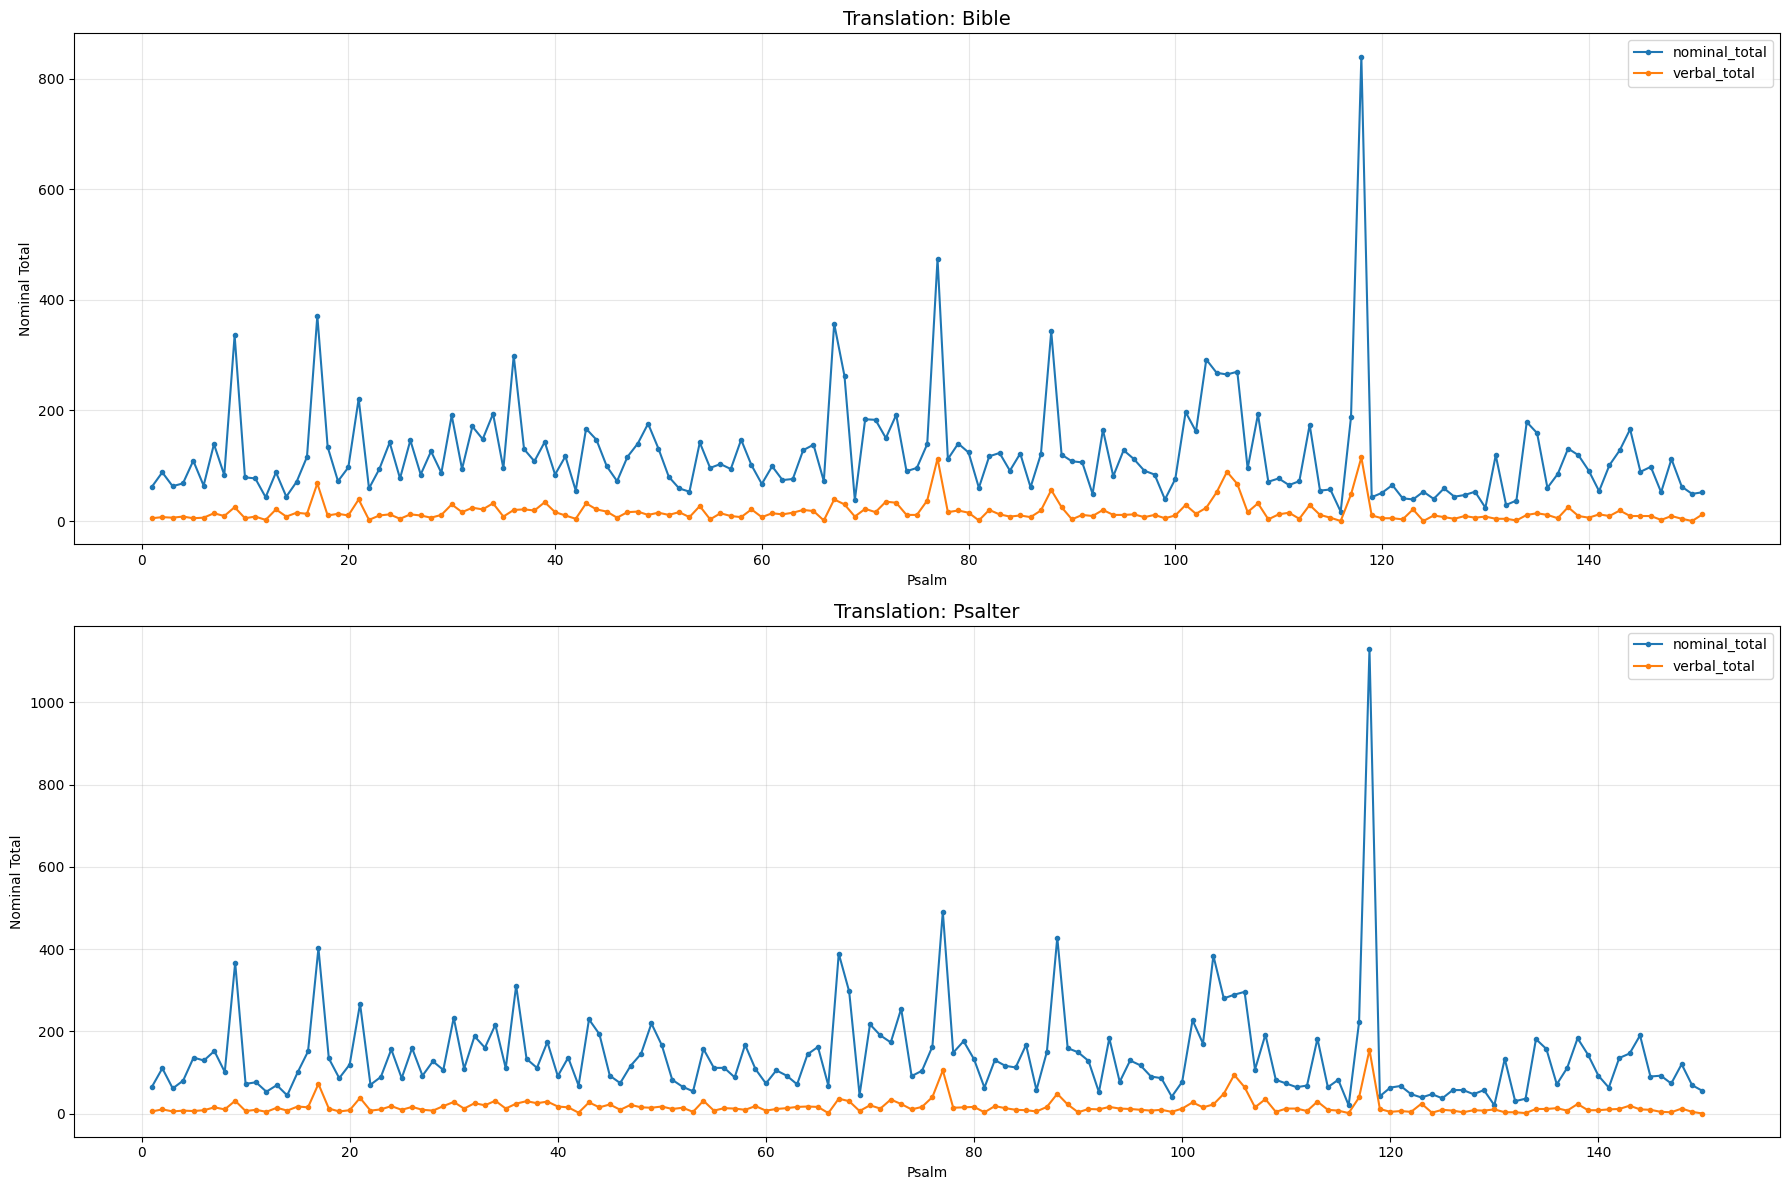

In [20]:
import matplotlib.pyplot as plt

# Create 2 separate stacked graphs
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, text in zip(axes, ca_df['Translation'].unique()):
    # Filter the data
    filtered_df = ca_df[ca_df['Translation'] == text]
    
    # Sort by Psalm so the line flows correctly from left to right
    filtered_df = filtered_df.sort_values('Psalm')
    
    # Use .plot() instead of .plot.bar() to make a line
    filtered_df.plot(x='Psalm', y='nominal_total', ax=ax, marker='o', markersize=3, linewidth=1.5)
    filtered_df.plot(x='Psalm', y='verbal_total', ax=ax, marker='o', markersize=3, linewidth=1.5)
    
    ax.set_title(f"Translation: {text}", fontsize=14)
    ax.set_ylabel("Nominal Total")
    ax.grid(True, alpha=0.3)  # Adds a faint grid to make reading points easier

plt.tight_layout()
plt.show()


In [23]:
small_ca = ca_df[['Translation', 'Psalm', 'nominal_total', 'verbal_total']]

# View the first few rows to make sure it looks right
small_ca.head()


,Translation,Psalm,nominal_total,verbal_total
0,Bible,1,62.0,5.0
1,Bible,2,88.0,7.0
2,Bible,3,63.0,6.0
3,Bible,4,68.0,8.0
4,Bible,5,109.0,5.0


In [24]:
def psalm_length(psalm):
    words = psalm.split()
    total = 0
    for word in words:
        total += len(word)
    return len(words), total/(len(words))


In [28]:
psalms[['word_count', 'avg_word_len']] = (
    psalms['verse']
    .apply(psalm_length)
    .apply(pd.Series)
)

psalms

,Unnamed: 0,tradition,text,psalm_num,verse,cleaned_verse,word_count,avg_word_len
0,0,Orthodox,Bible,1,Blessed is the man Who walks not in the counse...,blessed man walk counsel ungodly stand way sin...,133.0,3.917293
1,1,Orthodox,Bible,2,Why do the nations rage And the people meditat...,nation rage people meditate vain thing king ea...,199.0,4.130653
2,2,Orthodox,Bible,3,A psalm by David when he fled from the face of...,psalm david fled face son absalom olord afflic...,150.0,3.713333
3,3,Orthodox,Bible,4,For the End in psalms an ode by David You hear...,end psalm ode david heard icalled god righteou...,165.0,3.757576
4,4,Orthodox,Bible,5,For the End concerning the inheritance a psalm...,end concerning inheritance psalm david give ea...,248.0,4.048387
...,...,...,...,...,...,...,...,...
296,296,Orthodox,Psalter,146,The Lord doth build up Jerusalem; He shall gat...,lord doth build jerusalem ; shall gather toget...,164.0,4.390244
297,297,Orthodox,Psalter,147,"Praise the Lord, O Jerusalem; praise thy God, ...","praise lord , jerusalem ; praise thy god , zio...",126.0,4.476190
298,298,Orthodox,Psalter,148,Praise ye the Lord from the heavens; praise Hi...,praise ye lord heaven ; praise highest . prais...,207.0,4.285024
299,299,Orthodox,Psalter,149,"Sing unto the Lord a new song, His praise is i...","sing unto lord new song , praise congregation ...",137.0,4.408759


In [37]:
ca_df['word_count'] = psalms['word_count']
ca_df['avg_word_len'] = psalms['avg_word_len']

# ca_df

In [36]:
# Pass the column names as a list inside the brackets
new_df = ca_df[['Psalm', 'Translation', 'nominal_total', 'verbal_total', 'word_count', 'avg_word_len']]
new_df

,Psalm,Translation,nominal_total,verbal_total,word_count,avg_word_len
0,1,Bible,62.0,5.0,133.0,3.917293
1,2,Bible,88.0,7.0,199.0,4.130653
2,3,Bible,63.0,6.0,150.0,3.713333
3,4,Bible,68.0,8.0,165.0,3.757576
4,5,Bible,109.0,5.0,248.0,4.048387
...,...,...,...,...,...,...
296,146,Psalter,92.0,4.0,164.0,4.390244
297,147,Psalter,73.0,3.0,126.0,4.476190
298,148,Psalter,120.0,12.0,207.0,4.285024
299,149,Psalter,69.0,4.0,137.0,4.408759


In [39]:
new_df['nominal_pct'] = new_df['nominal_total'] / new_df['word_count'] * 100
new_df['verbal_pct'] = new_df['verbal_total'] / new_df['word_count'] * 100

new_df

,Psalm,Translation,nominal_total,verbal_total,word_count,avg_word_len,nominal_pct,verbal_pct
0,1,Bible,62.0,5.0,133.0,3.917293,46.616541,3.759398
1,2,Bible,88.0,7.0,199.0,4.130653,44.221106,3.517588
2,3,Bible,63.0,6.0,150.0,3.713333,42.000000,4.000000
3,4,Bible,68.0,8.0,165.0,3.757576,41.212121,4.848485
4,5,Bible,109.0,5.0,248.0,4.048387,43.951613,2.016129
...,...,...,...,...,...,...,...,...
296,146,Psalter,92.0,4.0,164.0,4.390244,56.097561,2.439024
297,147,Psalter,73.0,3.0,126.0,4.476190,57.936508,2.380952
298,148,Psalter,120.0,12.0,207.0,4.285024,57.971014,5.797101
299,149,Psalter,69.0,4.0,137.0,4.408759,50.364964,2.919708


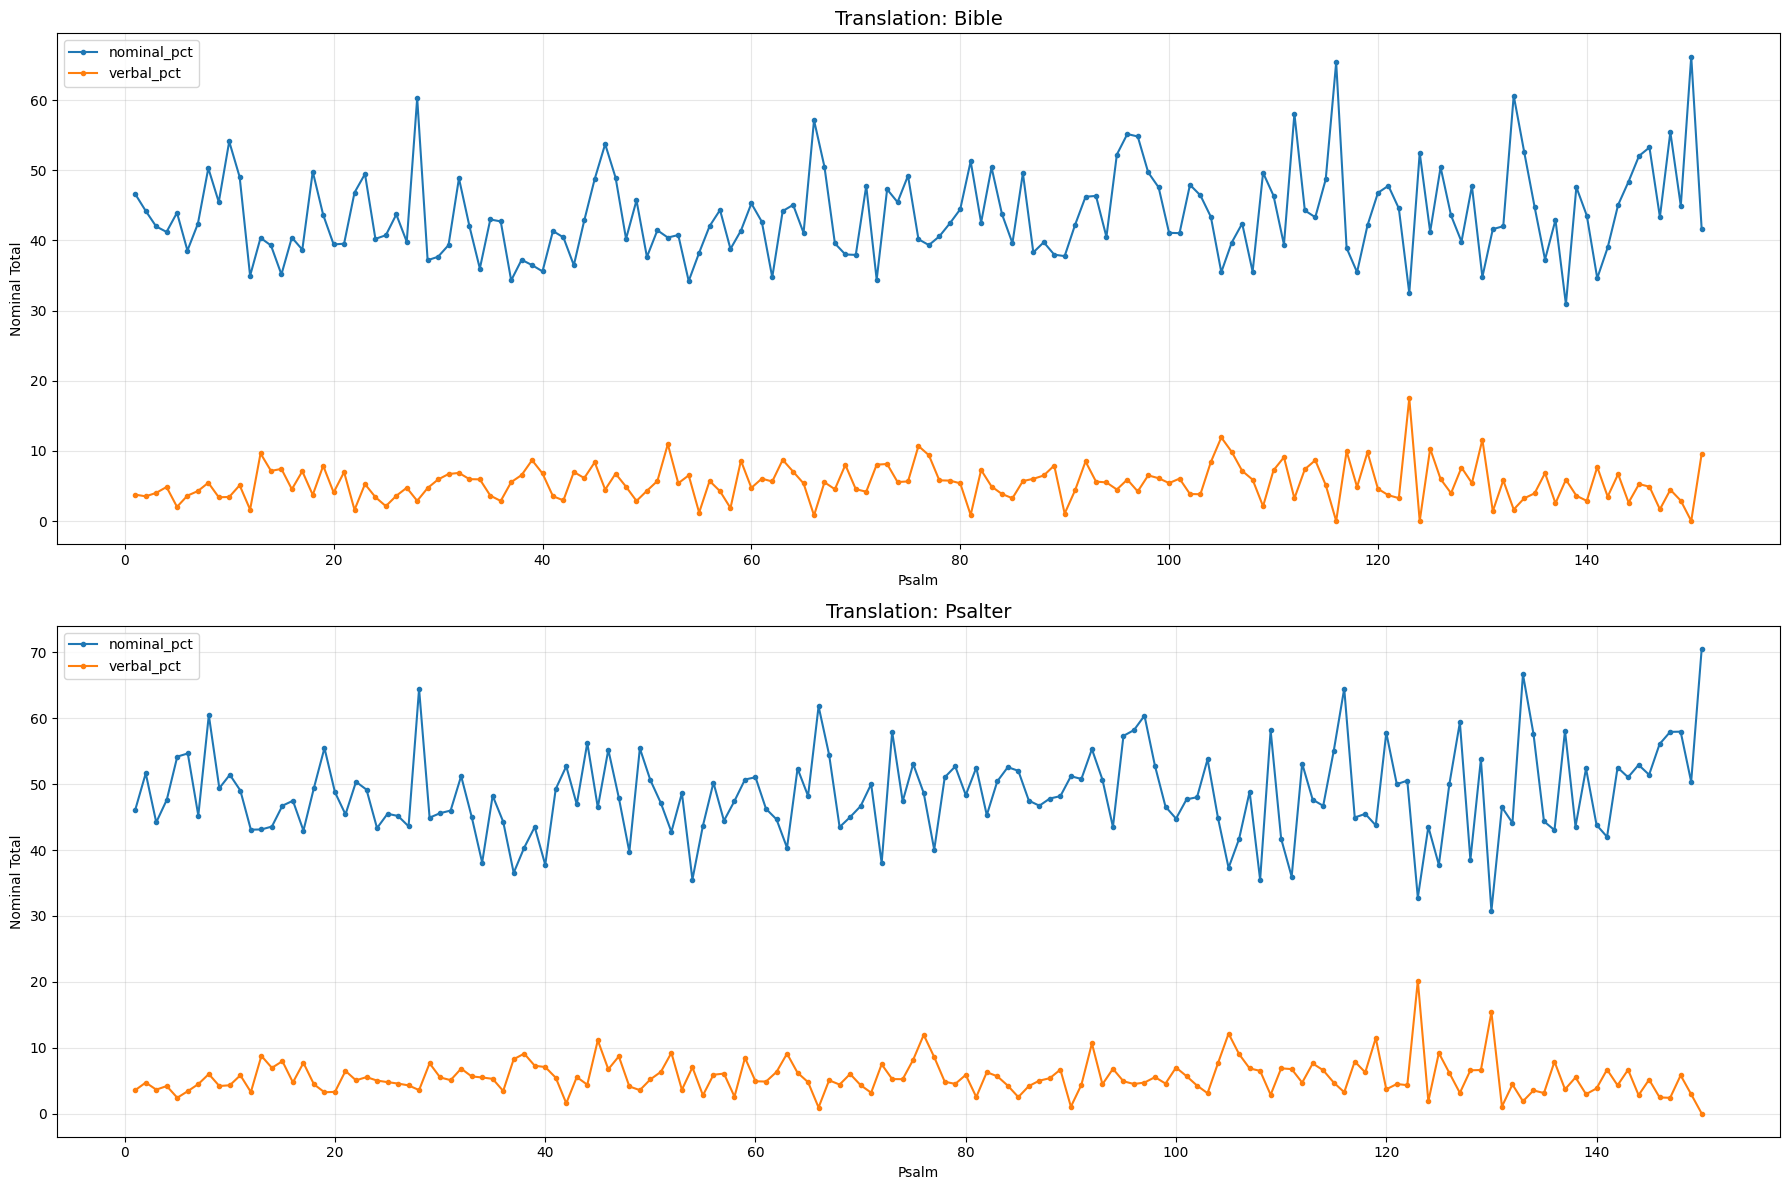

In [41]:
import matplotlib.pyplot as plt

# Create 2 separate stacked graphs
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, text in zip(axes, new_df['Translation'].unique()):
    # Filter the data
    filtered_df = new_df[new_df['Translation'] == text]
    
    # Sort by Psalm so the line flows correctly from left to right
    filtered_df = filtered_df.sort_values('Psalm')
    
    # Use .plot() instead of .plot.bar() to make a line
    filtered_df.plot(x='Psalm', y='nominal_pct', ax=ax, marker='o', markersize=3, linewidth=1.5)
    filtered_df.plot(x='Psalm', y='verbal_pct', ax=ax, marker='o', markersize=3, linewidth=1.5)
    
    ax.set_title(f"Translation: {text}", fontsize=14)
    ax.set_ylabel("Nominal Total")
    ax.grid(True, alpha=0.3)  # Adds a faint grid to make reading points easier

plt.tight_layout()
plt.show()


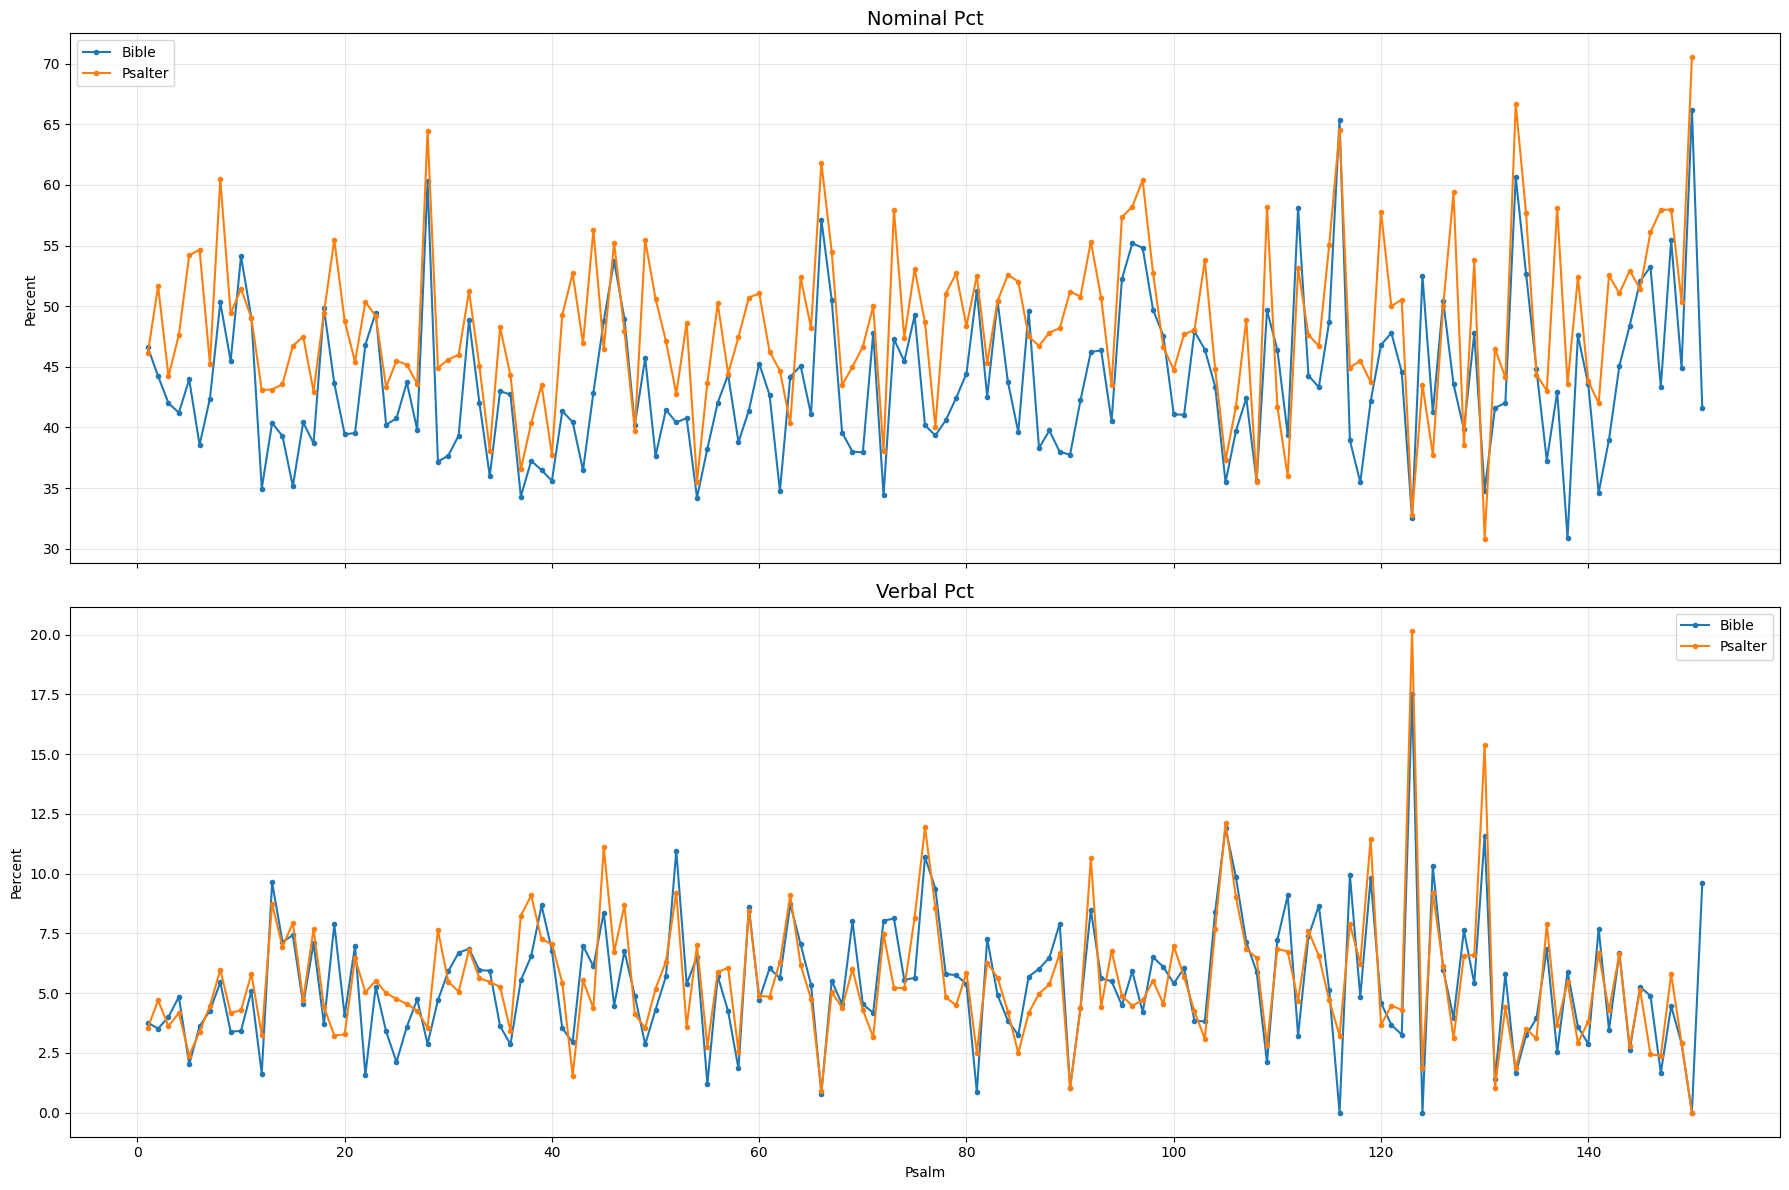

In [42]:
import matplotlib.pyplot as plt

metrics = ['nominal_pct', 'verbal_pct']

fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)

for ax, metric in zip(axes, metrics):

    for translation in new_df['Translation'].unique():
        filtered_df = (
            new_df[new_df['Translation'] == translation]
            .sort_values('Psalm')
        )

        ax.plot(
            filtered_df['Psalm'],
            filtered_df[metric],
            marker='o',
            markersize=3,
            linewidth=1.5,
            label=translation
        )

    ax.set_title(metric.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel('Percent')
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Psalm')

plt.tight_layout()
plt.show()

In [48]:
summary = new_df.groupby('Translation')[
    ['nominal_total', 'verbal_total', 'nominal_pct', 'verbal_pct']
].mean()

# Add difference row (Bible - Psalter)
summary.loc['Difference'] = (
    summary.loc['Bible'] - summary.loc['Psalter']
)

print("Averages across Noun and Verbs counts between the Psalter and Bible:")
summary

Averages across Noun and Verbs counts between the Psalter and Bible:


,nominal_total,verbal_total,nominal_pct,verbal_pct
Translation,,,,
Bible,121.013245,16.331126,43.680449,5.411260
Psalter,137.700000,16.600000,48.487286,5.498949
Difference,-16.686755,-0.268874,-4.806837,-0.087689


# Observations 

## Nomnial Totals 
* There is a bigger difference in nouns percentage bettween the Psalter and the Bible, compared to verbs within the Psalms 
    - A difference of about `16 words` or `4.08%`  
* Part of this is due to the fact of there being far more mouns than verbs within the Psalms, to begin with. 


## Verbal Features
* The difference in verbal elements between translations is much smaller.
* The Psalter contains only 0.27 more verbal words per Psalm on average (16.60 vs. 16.33).
* Verb usage differs by just 0.09 percentage points (5.50% vs. 5.41%).


## Overall
* The largest grammatical difference between the translations is in their use of nominal constructions, not verbal constructions.
* Relative to the Bible translation, the Psalter appears to employ a more noun-focused style, while verb usage remains nearly identical across the two translations.
* This difference is especially evident when comparing percentages: the nominal gap (4.81 percentage points) is over 50 times larger than the verbal gap (0.09 percentage points).

